# Image Classification with TensorFlow — End-to-End Project

## Overview
This notebook walks through an **end-to-end image classification pipeline** built using **TensorFlow and Keras**.  
The goal of this project is not only to achieve good predictive performance, but to demonstrate **production-ready machine learning practices** suitable for real-world deployment.

This project is part of my applied machine learning portfolio and emphasizes:
- Clean, reproducible workflows
- Thoughtful model design and evaluation
- Clear documentation and interpretability

---

## Problem Statement
Image classification is a foundational computer vision task with applications across many domains, including:
- Object recognition
- Medical imaging
- Autonomous systems
- Content moderation

In this project, we aim to:
> **Train a convolutional neural network that accurately classifies images into predefined categories using supervised learning.**

---

## High-Level Approach
The project follows a structured machine learning workflow:

1. Load and explore the dataset
2. Preprocess and augment image data
3. Establish a baseline CNN model
4. Apply **transfer learning** using a pretrained convolutional backbone
5. Train and tune the model using validation data
6. Evaluate performance using quantitative metrics and visual diagnostics
7. Export the trained model for inference and deployment

---

## Dataset
We use the **CIFAR-10** dataset, a widely-used benchmark dataset consisting of:
- 60,000 color images
- 10 distinct object classes
- 32×32 pixel resolution per image

The dataset is accessed via **TensorFlow Datasets (TFDS)** to ensure reproducibility and ease of use.

---

## Tools & Libraries
This project makes use of the following tools:
- **TensorFlow / Keras** for model building and training
- **TensorFlow Datasets (TFDS)** for dataset management
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **Scikit-learn** for evaluation metrics

---

## Expected Outputs
By the end of this notebook, we will have:
- A trained image classification model
- Saved evaluation artifacts (accuracy curves and confusion matrix)
- A TensorFlow **SavedModel** directory ready for inference
- A clean, modular codebase suitable for reuse and extension

---

## Notebook Organization
Each section of this notebook is clearly labeled and corresponds to a logical stage of the machine learning lifecycle.  
Detailed explanations precede each code block to make the workflow easy to follow for both technical and non-technical readers.

Let’s begin by importing the necessary libraries and setting up reproducibility.




## 2. Dataset Choice + Project Plan

### Dataset choice: CIFAR-10 (via TFDS)
For this portfolio project, we use **CIFAR-10**, a standard benchmark dataset for image classification.  
It includes **60,000 color images** across **10 object categories**.

We load it using **TensorFlow Datasets (TFDS)** because it:
- Makes this project **reproducible** (anyone can run it without manual downloads)
- Provides built-in metadata (class names, dataset sizes)
- Returns clean `(image, label)` pairs that integrate well with `tf.data`

### What we will do next
In the next steps we will:
1. Import libraries + set seeds for reproducibility
2. Load the dataset from TFDS
3. Visualize sample images to sanity-check labels and image quality


## 3. Imports + Reproducibility

### Goal
Set up the Python environment and make results as reproducible as possible.

### Why reproducibility matters
Deep learning involves randomness (weight initialization, shuffling, augmentation).  
Setting seeds helps keep experiments more consistent and easier to debug.



In [1]:
import sys
print(sys.executable)


c:\Users\Juant\OneDrive\Documents\ML-Projects\image-classifier-tensorflow\.venv\Scripts\python.exe


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# -------------------------
# Reproducibility settings
# -------------------------
# These seeds help reduce run-to-run variance.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU detected:", len(tf.config.list_physical_devices("GPU")) > 0)


c:\Users\Juant\OneDrive\Documents\ML-Projects\image-classifier-tensorflow\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU detected: False


## 4. Data Loading (TensorFlow Datasets)

### Goal
Load the CIFAR-10 dataset as `(image, label)` pairs using **TensorFlow Datasets (TFDS)**.

### Why TFDS?
Using TFDS makes this project:
- **Reproducible** (anyone can run it without manually downloading data)
- **Consistent** (standard dataset formatting)
- **Well-documented** (dataset metadata includes class names and counts)

### What we will extract
- `ds_train`, `ds_test`: dataset splits
- `ds_info`: metadata (sizes, label names)
- `class_names`: readable class labels for plots and reports
- `num_classes`: number of output classes for our model


In [3]:
import tensorflow_datasets as tfds

# -------------------------
# Dataset configuration
# -------------------------
# CIFAR-10 is a standard 10-class dataset.
# We'll use it to demonstrate a clean end-to-end ML workflow.
DATASET_NAME = "cifar10"

# Load dataset splits.
# as_supervised=True returns (image, label) pairs.
(ds_train, ds_test), ds_info = tfds.load(
    DATASET_NAME,
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Extract class names and count from metadata
class_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes

print("Class names:", class_names)
print("Number of classes:", num_classes)
print("Train examples:", ds_info.splits["train"].num_examples)
print("Test examples:", ds_info.splits["test"].num_examples)


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Train examples: 50000
Test examples: 10000


## 5. Visual Inspection (Sanity Check)

### Goal
Visually inspect a small sample of images to confirm:
- The dataset loads correctly
- Images look normal (no corruption)
- Labels match the visuals

### Why this matters
This is a fast, high-value step that can prevent wasted training time.



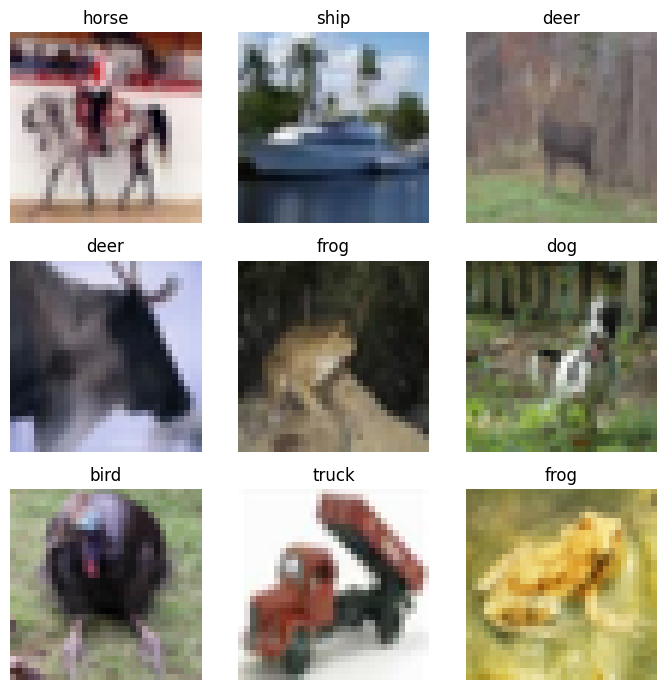

In [4]:
import matplotlib.pyplot as plt

def show_samples(dataset, class_names, n=9):
    """
    Display a grid of sample images from a tf.data dataset.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset yielding (image, label) pairs.
    class_names : list[str]
        Human-readable label names for display.
    n : int
        Number of images to show.

    Why we do this
    --------------
    Visual inspection helps detect issues early, such as:
    - labels not matching images
    - unexpected image format/channels
    - broken dataset pipelines
    """
    plt.figure(figsize=(7, 7))

    for i, (image, label) in enumerate(dataset.take(n)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(class_names[int(label)])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show 9 samples from the raw training set
show_samples(ds_train, class_names, n=9)


## 6. Train / Validation Split

### Goal
Create a validation set from the training data so we can:
- Monitor generalization during training (val accuracy/loss)
- Use callbacks like EarlyStopping and ReduceLROnPlateau
- Tune decisions (augmentation strength, learning rate, architecture) **without touching the test set**

### Why this matters 
In real ML work, the test set is treated like a final exam.  
We use the validation set during development so we don’t “leak” test information into our model choices.

### Implementation approach
1. Shuffle the training set once (reproducible)
2. Use `.take()` and `.skip()` to split into train and validation subsets


In [4]:
# -------------------------
# Split configuration
# -------------------------
SEED = 42
VAL_SPLIT = 0.10         # 10% validation split
SHUFFLE_BUFFER = 10_000  # shuffling buffer size for randomness

# Total training examples from TFDS metadata
train_total = ds_info.splits["train"].num_examples

# Compute split sizes
train_count = int(train_total * (1 - VAL_SPLIT))
val_count = train_total - train_count

print("Train count:", train_count)
print("Val count:", val_count)

# -------------------------
# Shuffle once, then split
# -------------------------
# reshuffle_each_iteration=False keeps the split stable across runs
ds_train_shuffled = ds_train.shuffle(
    SHUFFLE_BUFFER,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Use take/skip for an efficient split
ds_train_split = ds_train_shuffled.take(train_count)
ds_val_split = ds_train_shuffled.skip(train_count)


Train count: 45000
Val count: 5000


## 7. Preprocessing Pipeline (Resize + Normalize)

### Goal
Prepare images for training by ensuring:
- A consistent input shape compatible with transfer learning backbones
- Pixel values are normalized for stable optimization

### What we do
1. **Resize** CIFAR-10 images from 32×32 → 160×160  
2. **Normalize** pixel values from 0–255 → 0–1

### Why this matters
Transfer learning models (MobileNetV2/EfficientNet) expect larger images than CIFAR-10 provides.  
Normalization helps gradients behave more predictably and speeds up convergence.


In [12]:
import tensorflow as tf

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    """
    Resize + normalize an image.

    Parameters
    ----------
    image : tf.Tensor
        Raw image tensor from TFDS (often uint8, shape ~ (32, 32, 3)).
    label : tf.Tensor
        Integer class label.

    Returns
    -------
    image : tf.Tensor
        Float32 image resized to IMG_SIZE, scaled to [0, 1].
    label : tf.Tensor
        Unchanged integer label.

    Why normalize?
    - Keeps inputs in a stable numeric range for training
    - Improves optimizer stability and convergence
    """
    # Resize to match transfer learning model expectations
    image = tf.image.resize(image, IMG_SIZE)

    # Convert to float32 and scale to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


## 8. Data Augmentation (Train Only)

### Goal
Improve generalization by exposing the model to realistic variations:
- small rotations
- flips
- zoom

### Why augmentation is train-only
Validation and test sets represent “real” data.  
If we augment them, our metrics become misleading.

### Interview note
Augmentation is one of the easiest and most effective ways to reduce overfitting in image models.


In [6]:
# -------------------------
# Data augmentation layers
# -------------------------
# These are intentionally mild to avoid destroying CIFAR-10 signal.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

# Force build with a dummy tensor to confirm shape compatibility
_dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3))
_ = data_augmentation(_dummy)

print("Augmentation layer ready for shape:", _dummy.shape)


Augmentation layer ready for shape: (1, 160, 160, 3)


## 9. Build Efficient `tf.data` Pipelines (Train / Val / Test)

### Goal
Create performant dataset pipelines for training and evaluation.

### What we do
- Apply preprocessing to all splits
- Apply augmentation to training only
- Batch examples for efficient GPU/CPU usage
- Prefetch to overlap CPU preprocessing with model training

### Why this matters
Efficient input pipelines can significantly speed up training and reduce bottlenecks.
This is a production-style best practice.


In [7]:
# -------------------------
# Final tf.data pipelines
# -------------------------
train_ds = (
    ds_train_split
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    ds_val_split
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("train_ds:", train_ds)
print("val_ds:", val_ds)
print("test_ds:", test_ds)


train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
val_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
test_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 10. Visual Check: Preprocessed vs Augmented Samples

### Goal
Before training, confirm that:
- Preprocessing produces correctly shaped, normalized images
- Augmentation is reasonable (not overly destructive)

### Why this matters
If preprocessing or augmentation is wrong, training will waste time or converge poorly.
This check is a quick “quality gate” before modeling.


Preprocessed (val_ds) samples:


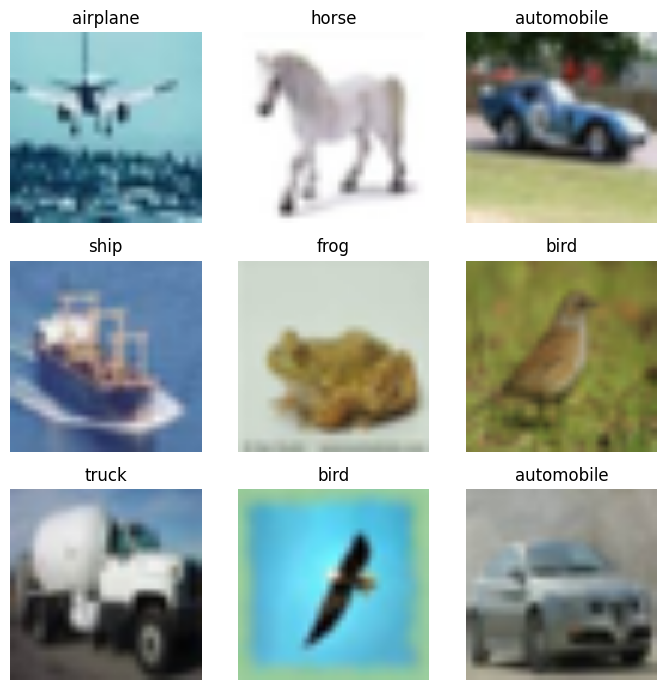

Augmented (train_ds) samples:


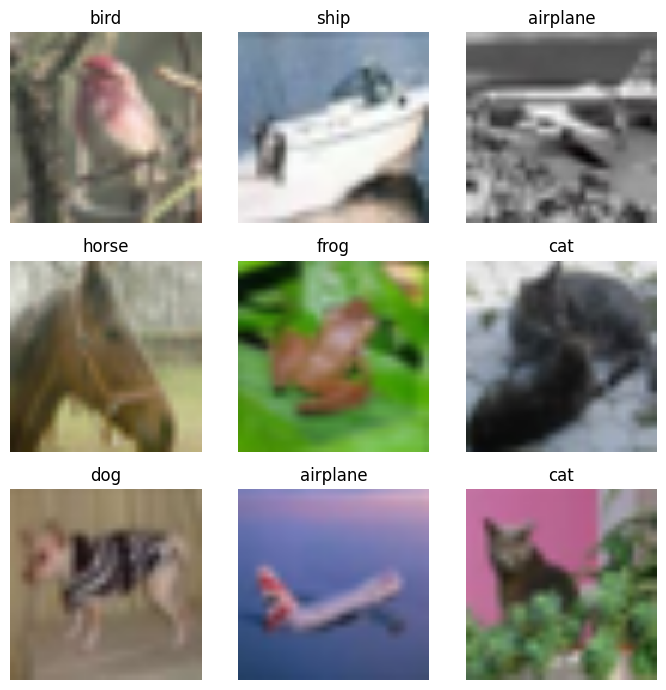

In [9]:
def show_samples_from_pipeline(dataset, class_names, n=9):
    """
    Display n samples from a *batched* pipeline (train_ds / val_ds / test_ds).

    Why this helper exists:
    - Our final pipelines are batched, so we need to unbatch to visualize cleanly.
    """
    plt.figure(figsize=(7, 7))
    count = 0

    for batch_images, batch_labels in dataset.take(1):
        for i in range(min(n, batch_images.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(batch_images[i].numpy(), interpolation="nearest")
            plt.title(class_names[int(batch_labels[i])])
            plt.axis("off")
            count += 1
        break

    plt.tight_layout()
    plt.show()

print("Preprocessed (val_ds) samples:")
show_samples_from_pipeline(val_ds, class_names, n=9)

print("Augmented (train_ds) samples:")
show_samples_from_pipeline(train_ds, class_names, n=9)


## 10A. Baseline-Specific Preprocessing (Native CIFAR-10 Resolution)

### Why this is necessary
CIFAR-10 images are only **32×32 pixels**.

For the **baseline CNN**, our goal is:
- Fast training
- Low compute cost
- A quick performance reference point

Resizing CIFAR-10 to large resolutions (e.g., 160×160) on **CPU** makes training extremely slow and defeats the purpose of a baseline.

Therefore, we create a **separate preprocessing pipeline** for the baseline model that:
- Keeps images at their native resolution
- Applies normalization only
- Avoids expensive resizing


In [8]:
# -------------------------
# Baseline-specific preprocessing
# -------------------------
BASELINE_IMG_SIZE = (32, 32)  # native CIFAR-10 resolution

def preprocess_baseline(image, label):
    """
    Preprocessing for baseline CNN only.

    Steps:
    - Keep original 32x32 resolution
    - Convert to float32
    - Normalize pixel values to [0, 1]

    Why this differs from transfer learning:
    - Baseline models are meant to be fast and lightweight
    - Large image resizing is unnecessary and costly on CPU
    """
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


## 10B. Baseline `tf.data` Pipelines

We now build separate training and validation pipelines specifically for the baseline CNN.

These pipelines:
- Use native-resolution images
- Do NOT use data augmentation
- Are optimized for fast CPU training


In [9]:
# -------------------------
# Baseline tf.data pipelines
# -------------------------
# These pipelines are intentionally lightweight to keep baseline
# training fast and CPU-friendly.

baseline_train_ds = (
    ds_train_split
    # Apply baseline-specific preprocessing:
    # - keep native 32x32 resolution
    # - normalize pixel values to [0, 1]
    .map(preprocess_baseline, num_parallel_calls=AUTOTUNE)

    # Group samples into batches to improve training throughput
    .batch(BATCH_SIZE)

    # Prefetch batches to overlap CPU preprocessing with model execution
    # This helps prevent the model from waiting on data input
    .prefetch(AUTOTUNE)
)

baseline_val_ds = (
    ds_val_split
    # Apply the same preprocessing to validation data
    # (no augmentation, no resizing)
    .map(preprocess_baseline, num_parallel_calls=AUTOTUNE)

    # Batch validation samples for efficient evaluation
    .batch(BATCH_SIZE)

    # Prefetch for consistent performance during validation
    .prefetch(AUTOTUNE)
)


## 11. Baseline CNN — Compile + Train

### Goal
Train a simple baseline CNN to establish a performance reference point before transfer learning.

### Why we do this first
A baseline model helps answer questions like:
- “How did you know transfer learning improved results?”
- “What was your simplest working solution?”
- “What did you try before using pretrained networks?”

### Notes (CPU-friendly)
Since I'm  currently training on a CPU (GPU detected: False), I keep:
- Model size small
- Epoch count modest
- Early stopping enabled


In [10]:
from tensorflow.keras import layers, models

def build_baseline_cnn(num_classes):
    """
    Build a lightweight CNN baseline.

    Architecture rationale
    ----------------------
    - Convolution layers learn local spatial patterns (edges → textures → shapes).
    - Pooling reduces spatial size to lower computation and improve invariance.
    - GlobalAveragePooling reduces parameters vs Flatten (helps generalization).
    - Dropout provides regularization to reduce overfitting.
    """
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        # Output: probability distribution over classes
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

baseline_model = build_baseline_cnn(num_classes)

# Compile with a standard optimizer + multiclass loss
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Baseline Training (with Callbacks)

### Goal
Train the baseline CNN while monitoring validation performance.

### Callbacks used
- **EarlyStopping**: stops training when validation accuracy stops improving
- **ReduceLROnPlateau**: lowers learning rate when validation loss plateaus

### Why callbacks matter
They make training more stable and efficient, and they’re standard practice in production ML workflows.


In [13]:
# -------------------------
# Training callbacks
# -------------------------
# These callbacks help control training behavior and prevent overfitting,
# especially important when training on CPU.

baseline_callbacks = [
    # Stop training if validation accuracy stops improving.
    # This prevents overfitting and avoids wasting compute.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,              # small patience = faster feedback on CPU
        restore_best_weights=True
    ),

    # Reduce learning rate when validation loss plateaus.
    # This allows the optimizer to make finer adjustments late in training.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,              # cut LR in half when plateaued
        patience=1,
        min_lr=1e-6              # prevent LR from becoming too small
    )
]

# Keep baseline training intentionally short.
# This model is only used as a reference point before transfer learning.
BASELINE_EPOCHS = 8

# -------------------------
# Train baseline model
# -------------------------
baseline_history = baseline_model.fit(
    baseline_train_ds,
    validation_data=baseline_val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=baseline_callbacks
)



Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 156s 106ms/step - accuracy: 0.3522 - loss: 1.7249 - val_accuracy: 0.4900 - val_loss: 1.3935 - learning_rate: 0.0010
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.5084 - loss: 1.3459 - val_accuracy: 0.5746 - val_loss: 1.1964 - learning_rate: 0.0010
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 137s 97ms/step - accuracy: 0.5739 - loss: 1.1781 - val_accuracy: 0.6044 - val_loss: 1.1256 - learning_rate: 0.0010
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.6214 - loss: 1.0640 - val_accuracy: 0.6336 - val_loss: 1.0427 - learning_rate: 0.0010
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 145s 98ms/step - accuracy: 0.6554 - loss: 0.9795 - val_accuracy: 0.6454 - val_loss: 1.0092 - learning_rate: 0.0010
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 129s 88ms/step - accuracy: 0.6814 - loss: 0.9031 - val_accuracy: 0.6664 - val_loss: 0.9449 - learning_rate: 0.0010
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 126s 90ms/step - accu

## 13. Transfer Learning Training (Safe + Efficient on CPU)

### Goal
Train a transfer learning model using **MobileNetV2** in a CPU-friendly way by:
1. Training only the new classifier head first (backbone frozen)
2. Using callbacks to avoid wasted epochs
3. Keeping the input size reasonable for CPU training

### Why this approach is “safe”
- Freezing the backbone prevents destroying pretrained ImageNet features early
- EarlyStopping prevents overfitting and saves time
- ReduceLROnPlateau helps refine learning when progress stalls

### CPU note
Transfer learning on CPU can still be slow, especially with large input images.
If training feels too slow, we will reduce `IMG_SIZE` from `(160,160)` → `(96,96)` or `(128,128)`.


In [14]:
# -------------------------
# CPU-friendly recommendation
# -------------------------
# If you're on CPU and training is slow, consider dropping IMG_SIZE to (96, 96) or (128, 128)
# BEFORE training transfer learning.
#
# Example:
# IMG_SIZE = (128, 128)
# ...then rebuild train_ds/val_ds/test_ds with preprocess() and rerun training.
#
# For now, we proceed with your current IMG_SIZE setting.


## 14. Build the Transfer Learning Model (MobileNetV2)

### Goal
Use MobileNetV2 pretrained on ImageNet as a feature extractor, then add a small classifier head.

### What’s trainable?
- Initially: **ONLY the head is trainable**
- Backbone is frozen (`base_model.trainable = False`)

This is the standard, safe starting point for transfer learning.


In [11]:
from tensorflow.keras import layers, Model

def build_mobilenetv2_transfer(num_classes):
    """
    Build a MobileNetV2 transfer learning classifier.

    Workflow
    --------
    1) Load MobileNetV2 without the ImageNet classifier head
    2) Freeze backbone (train only the new head first)
    3) Add pooling + dropout + Dense softmax head
    """
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,     # remove ImageNet classifier layers
        weights="imagenet"
    )

    # Freeze backbone for initial training (head-only training)
    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = inputs

  

    # Feature extraction
    x = base_model(x, training=False)

    # Convert feature maps -> single feature vector
    x = layers.GlobalAveragePooling2D()(x)

    # Regularization for the new classifier head
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="mobilenetv2_transfer")
    return model

transfer_model = build_mobilenetv2_transfer(num_classes)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 15. Train the Transfer Learning Model (Frozen Backbone)

### Goal
Train the **classifier head** on top of a frozen MobileNetV2 backbone.

### Why this is the safest starting point
- The backbone already contains strong general visual features (ImageNet).
- Freezing prevents “wrecking” those features early.
- Training only the head is faster and more stable—especially on CPU.

### What we expect
- Faster improvement than the baseline
- Higher validation accuracy
- EarlyStopping will stop training when improvement stalls


In [13]:
# -------------------------
# Callbacks for efficient training
# -------------------------
transfer_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    )
]

# CPU-friendly starter
TRANSFER_EPOCHS = 6

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRANSFER_EPOCHS,
    callbacks=transfer_callbacks
)


Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2959s 2s/step - accuracy: 0.7433 - loss: 0.7416 - val_accuracy: 0.8016 - val_loss: 0.5691 - learning_rate: 0.0010
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7292s 5s/step - accuracy: 0.8018 - loss: 0.5852 - val_accuracy: 0.8100 - val_loss: 0.5482 - learning_rate: 0.0010
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5737s 4s/step - accuracy: 0.8076 - loss: 0.5581 - val_accuracy: 0.8158 - val_loss: 0.5379 - learning_rate: 0.0010
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31786s 23s/step - accuracy: 0.8134 - loss: 0.5470 - val_accuracy: 0.8124 - val_loss: 0.5412 - learning_rate: 0.0010
Epoch 5/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3153s 2s/step - accuracy: 0.8230 - loss: 0.5121 - val_accuracy: 0.8156 - val_loss: 0.5242 - learning_rate: 5.0000e-04
Epoch 6/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6619s 5s/step - accuracy: 0.8264 - loss: 0.5065 - val_accuracy: 0.8174 - val_loss: 0.5210 - learning_rate: 5.0000e-04


## 16. Transfer Learning Curves (Accuracy + Loss)

### Goal
Visualize training to detect:
- Overfitting (train improves but val degrades)
- Underfitting (both low)
- Healthy learning (both improve and stay close)




In [14]:
def plot_history(history, title_prefix="Model"):
    """
    Plot accuracy and loss curves from a Keras History object.
    """
    hist = history.history

    # Accuracy plot
    plt.figure(figsize=(7, 4))
    plt.plot(hist.get("accuracy", []), label="train_accuracy")
    plt.plot(hist.get("val_accuracy", []), label="val_accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss plot
    plt.figure(figsize=(7, 4))
    plt.plot(hist.get("loss", []), label="train_loss")
    plt.plot(hist.get("val_loss", []), label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


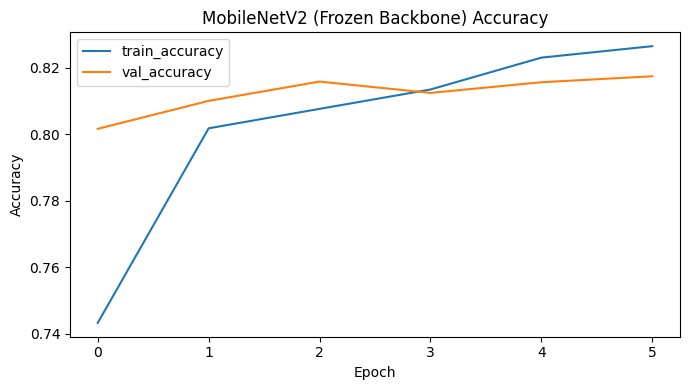

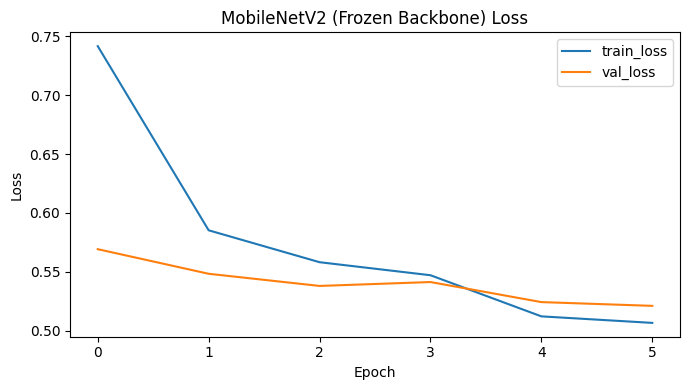

In [15]:
plot_history(transfer_history, title_prefix="MobileNetV2 (Frozen Backbone)")


## 17. Model Export (SavedModel + Keras Format)

### Goal
Export the trained transfer learning model so it can be:
- Loaded later without re-training
- Used for inference scripts / demos
- Shared with recruiters (they can run inference quickly)

### What we will save
1) **SavedModel** folder (recommended for deployment)
2) **`.keras`** single-file model (recommended for portability in modern Keras)

We also save:
- `class_names.json` so label decoding is consistent during inference


In [16]:
import os, json
from datetime import datetime

# -------------------------
# Output directories
# -------------------------
MODELS_DIR = os.path.join("models")
SAVEDMODEL_DIR = os.path.join(MODELS_DIR, "saved_model")
KERAS_DIR = os.path.join(MODELS_DIR, "keras")

os.makedirs(SAVEDMODEL_DIR, exist_ok=True)
os.makedirs(KERAS_DIR, exist_ok=True)

# Versioned name (helps you keep multiple runs/models)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_tag = f"mobilenetv2_frozen_{timestamp}"

savedmodel_path = os.path.join(SAVEDMODEL_DIR, model_tag)
keras_path = os.path.join(KERAS_DIR, f"{model_tag}.keras")

print("SavedModel path:", savedmodel_path)
print("Keras path:", keras_path)

# -------------------------
# Save label map
# -------------------------
labels_path = os.path.join(MODELS_DIR, "class_names.json")
with open(labels_path, "w") as f:
    json.dump(class_names, f, indent=2)

print("Saved class names to:", labels_path)

# -------------------------
# Export model
# -------------------------
# NOTE: In TF 2.20+, `model.export(...)` is the preferred API for SavedModel export.
# If your environment doesn't support it, we'll fall back automatically.
try:
    transfer_model.export(savedmodel_path)
    print("✅ Exported SavedModel via model.export()")
except Exception as e:
    print("model.export() failed, falling back to tf.saved_model.save(). Reason:", e)
    import tensorflow as tf
    tf.saved_model.save(transfer_model, savedmodel_path)
    print("✅ Exported SavedModel via tf.saved_model.save()")

# Save modern Keras single-file format
transfer_model.save(keras_path)
print("✅ Exported .keras model")


SavedModel path: models\saved_model\mobilenetv2_frozen_20260103_161143
Keras path: models\keras\mobilenetv2_frozen_20260103_161143.keras
Saved class names to: models\class_names.json
INFO:tensorflow:Assets written to: models\saved_model\mobilenetv2_frozen_20260103_161143\assets


INFO:tensorflow:Assets written to: models\saved_model\mobilenetv2_frozen_20260103_161143\assets


Saved artifact at 'models\saved_model\mobilenetv2_frozen_20260103_161143'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_169')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1791955205392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791955205776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958401296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791955204432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791955205584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958401872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958402640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958402448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958402832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1791958401104: TensorSpec(shape=(), dtype=tf.resource, name=

## 18. Load the Exported Model (Quick Verification)

### Goal
Verify the exported model loads correctly by reloading it and running a forward pass.

### Why this matters
It confirms your export artifact is valid and usable outside the training session.


In [17]:
import tensorflow as tf

# Load the .keras model (fast + reliable)
reloaded_model = tf.keras.models.load_model(keras_path)

# Run a quick forward pass on one batch to verify it works
x_batch, y_batch = next(iter(test_ds.take(1)))
proba = reloaded_model.predict(x_batch[:4], verbose=0)

print("Reloaded model output shape:", proba.shape)  # (4, num_classes)
print("Sum of probabilities (should be ~1):", proba[0].sum())


Reloaded model output shape: (4, 10)
Sum of probabilities (should be ~1): 1.0


## 19. Inference Demo (Predictions on Test Images)

### Goal
Run inference on a few test images and display:
- Image
- True label
- Predicted label
- Confidence score




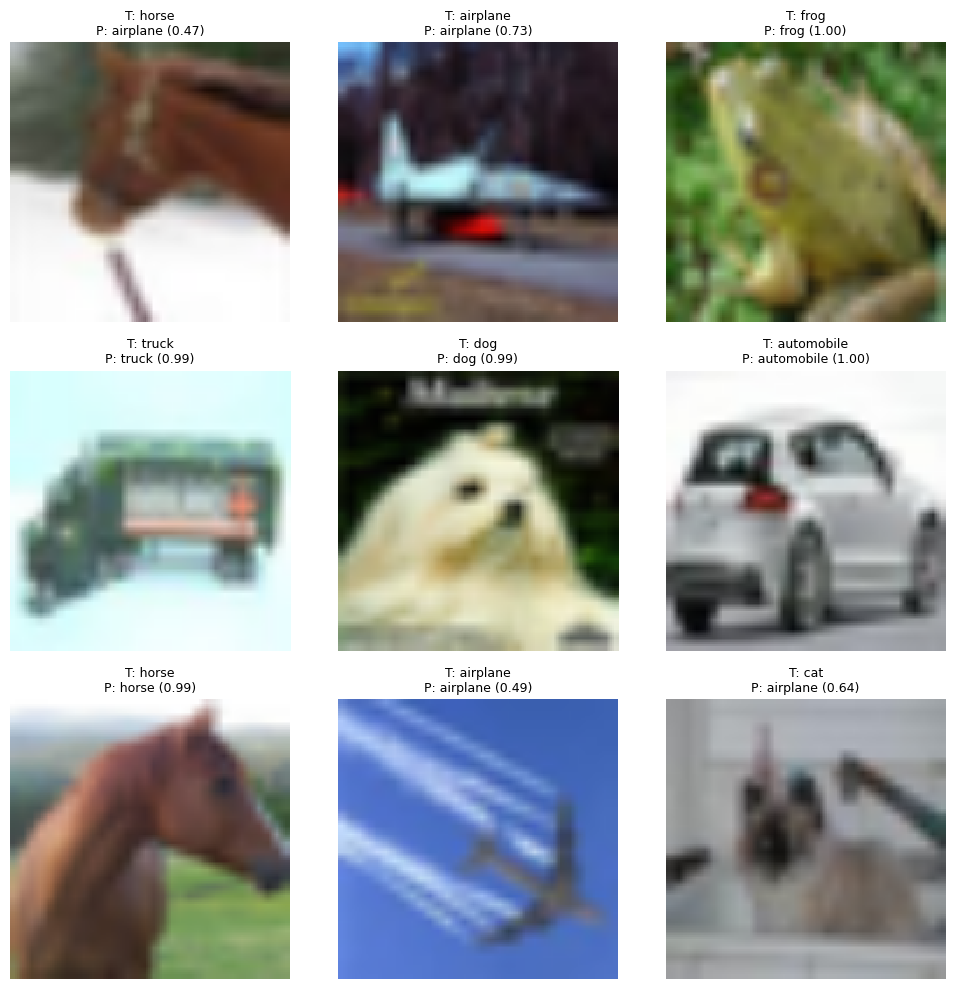

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def predict_and_show(model, dataset, class_names, n=9):
    """
    Predict on one batch from a dataset and show n images with:
    - true label
    - predicted label
    - confidence

    Assumes dataset yields (image, label) where image is already preprocessed
    to match model input (IMG_SIZE, float32, scaled).
    """
    x, y_true = next(iter(dataset.take(1)))

    # Predict probabilities for the batch
    y_proba = model.predict(x, verbose=0)

    # Convert to predicted labels + confidences
    y_pred = np.argmax(y_proba, axis=1)
    conf = np.max(y_proba, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(min(n, x.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(x[i].numpy(), interpolation="nearest")
        true_name = class_names[int(y_true[i])]
        pred_name = class_names[int(y_pred[i])]
        score = conf[i]

        title = f"T: {true_name}\nP: {pred_name} ({score:.2f})"
        plt.title(title, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run inference demo using the reloaded model (proves exported model works)
predict_and_show(reloaded_model, test_ds, class_names, n=9)


## 20. Inference on a Single Image (Reusable Utility)

### Goal
Create a small helper that can predict on a single image (e.g., for a script / app).

### Notes
- Expects a **raw image** (uint8 or float), converts it into model-ready format:
  - resize to `IMG_SIZE`
  - scale to `[0, 1]`
  - add batch dimension


In [19]:
def preprocess_single_image(img, img_size=IMG_SIZE):
    """
    Preprocess a single image for inference.

    Parameters
    ----------
    img : tf.Tensor or np.ndarray
        Raw image with shape (H, W, 3)
    img_size : tuple
        Target size (height, width)

    Returns
    -------
    tf.Tensor
        Preprocessed image with shape (1, H, W, 3)
    """
    if not isinstance(img, tf.Tensor):
        img = tf.convert_to_tensor(img)

    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)  # add batch dimension
    return img

def predict_single(model, img, class_names):
    """
    Predict label + confidence for a single image.
    """
    x = preprocess_single_image(img)
    proba = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(proba))
    confidence = float(np.max(proba))
    return class_names[pred_idx], confidence, proba

# Demo using a raw image from TFDS (not preprocessed)
raw_img, raw_label = next(iter(ds_test.take(1)))
pred_name, conf, _ = predict_single(reloaded_model, raw_img, class_names)

print("True:", class_names[int(raw_label)])
print("Pred:", pred_name, "| confidence:", round(conf, 3))


True: horse
Pred: airplane | confidence: 0.468


In [21]:
import numpy as np

# Recompute predictions (required after kernel restart)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

y_proba = transfer_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print("Recomputed y_true / y_pred")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


Recomputed y_true / y_pred
y_true shape: (10000,)
y_pred shape: (10000,)


In [23]:
# Recompute evaluation metrics (required after kernel restart)
transfer_val_loss, transfer_val_acc = transfer_model.evaluate(val_ds, verbose=0)
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds, verbose=0)

print("Val accuracy:", transfer_val_acc)
print("Test accuracy:", transfer_test_acc)


Val accuracy: 0.8173999786376953
Test accuracy: 0.815500020980835


## 21. Save Evaluation Metrics to Disk (Portfolio + Reproducibility)

### Goal
Save your key evaluation outputs so a reviewer can verify results without rerunning the whole notebook:
- `classification_report.txt`
- `metrics.json` (accuracy/loss + run metadata)




In [24]:
import os, json
from datetime import datetime
from sklearn.metrics import classification_report

# -------------------------
# Ensure metrics folder exists
# -------------------------
METRICS_DIR = os.path.join("reports", "metrics")
os.makedirs(METRICS_DIR, exist_ok=True)

# -------------------------
# Save classification report
# -------------------------
report_txt = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

report_path = os.path.join(METRICS_DIR, "classification_report_mobilenetv2_frozen.txt")
with open(report_path, "w") as f:
    f.write(report_txt)

print("Saved classification report to:", report_path)

# -------------------------
# Save a compact metrics JSON
# -------------------------
metrics_payload = {
    "model_name": "mobilenetv2_frozen",
    "timestamp": datetime.now().isoformat(),
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "val_accuracy": float(transfer_val_acc),
    "test_accuracy": float(transfer_test_acc),
    "val_loss": float(transfer_val_loss),
    "test_loss": float(transfer_test_loss),
}

metrics_path = os.path.join(METRICS_DIR, "metrics_mobilenetv2_frozen.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_payload, f, indent=2)

print("Saved metrics JSON to:", metrics_path)


Saved classification report to: reports\metrics\classification_report_mobilenetv2_frozen.txt
Saved metrics JSON to: reports\metrics\metrics_mobilenetv2_frozen.json


## 22. Create a Runnable Inference Script (`src/inference.py`)

### Goal
Create a script a recruiter can run from the command line to:
- load your exported `.keras` model
- load `class_names.json`
- run predictions on N test images (CIFAR-10 via TFDS)
- print a compact summary and optionally save a prediction grid image

### Why this matters
This proves your project is not “just a notebook.”
It shows basic software engineering: loading artifacts, preprocessing, and inference.


In [25]:
# This cell writes src/inference.py into your repo.
import os

SRC_DIR = os.path.join("src")
os.makedirs(SRC_DIR, exist_ok=True)

inference_py_path = os.path.join(SRC_DIR, "inference.py")

inference_code = r'''"""
Inference script for the Image Classifier (TensorFlow).

Usage examples:
--------------
# Run inference on 9 CIFAR-10 test images
python src/inference.py --model models/keras/<your_model>.keras --num 9

# Save a grid image of predictions
python src/inference.py --model models/keras/<your_model>.keras --num 9 --save-grid reports/figures/pred_grid.png
"""

import argparse
import json
import os
from typing import List, Tuple

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Run inference using an exported Keras model.")
    parser.add_argument("--model", type=str, required=True, help="Path to exported .keras model file.")
    parser.add_argument("--class-names", type=str, default="models/class_names.json",
                        help="Path to class_names.json (default: models/class_names.json).")
    parser.add_argument("--dataset", type=str, default="cifar10", help="TFDS dataset name (default: cifar10).")
    parser.add_argument("--split", type=str, default="test", help="TFDS split (default: test).")
    parser.add_argument("--img-size", type=int, nargs=2, default=[160, 160],
                        help="Image size as two ints: H W (default: 160 160). Must match training.")
    parser.add_argument("--num", type=int, default=9, help="Number of images to run inference on (default: 9).")
    parser.add_argument("--seed", type=int, default=42, help="Random seed for sampling (default: 42).")
    parser.add_argument("--save-grid", type=str, default=None,
                        help="Optional path to save prediction grid image (e.g., reports/figures/pred_grid.png).")
    return parser.parse_args()


def load_class_names(path: str) -> List[str]:
    with open(path, "r") as f:
        return json.load(f)


def preprocess(image: tf.Tensor, label: tf.Tensor, img_size: Tuple[int, int]) -> Tuple[tf.Tensor, tf.Tensor]:
    """
    Match training-time preprocessing:
    - resize
    - float32
    - scale to [0, 1]
    """
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def sample_batch(ds: tf.data.Dataset, num: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Take a reasonably-sized batch and sample `num` items from it for display.
    """
    # Grab one batch of 128 for sampling
    x_batch, y_batch = next(iter(ds.batch(128).take(1)))
    rng = np.random.default_rng(seed)
    idx = rng.choice(x_batch.shape[0], size=min(num, x_batch.shape[0]), replace=False)
    return x_batch.numpy()[idx], y_batch.numpy()[idx]


def make_grid(images: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, conf: np.ndarray,
              class_names: List[str], title: str = "Predictions") -> None:
    n = images.shape[0]
    grid = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(10, 10))
    for i in range(n):
        ax = plt.subplot(grid, grid, i + 1)
        plt.imshow(images[i], interpolation="nearest")
        t = class_names[int(y_true[i])]
        p = class_names[int(y_pred[i])]
        c = float(conf[i])
        ax.set_title(f"T:{t}\nP:{p} ({c:.2f})", fontsize=9)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def main() -> None:
    args = parse_args()

    if not os.path.exists(args.model):
        raise FileNotFoundError(f"Model file not found: {args.model}")

    class_names = load_class_names(args.class_names)
    img_size = (args.img_size[0], args.img_size[1])

    # Load model
    model = tf.keras.models.load_model(args.model)

    # Load TFDS data (raw), then preprocess
    ds = tfds.load(args.dataset, split=args.split, as_supervised=True)
    ds = ds.map(lambda x, y: preprocess(x, y, img_size), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    # Sample images
    images, labels = sample_batch(ds, num=args.num, seed=args.seed)

    # Predict
    proba = model.predict(images, verbose=0)
    pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)

    # Print a compact text summary
    correct = (pred == labels).sum()
    print(f"Ran inference on {len(labels)} images | correct: {correct}/{len(labels)}")
    for i in range(len(labels)):
        t = class_names[int(labels[i])]
        p = class_names[int(pred[i])]
        print(f"[{i}] true={t:>10s} | pred={p:>10s} | conf={conf[i]:.3f}")

    # Visualize
    make_grid(images, labels, pred, conf, class_names, title="Inference Demo")

    # Optionally save the grid
    if args.save_grid:
        os.makedirs(os.path.dirname(args.save_grid), exist_ok=True)
        plt.figure(figsize=(10, 10))
        n = images.shape[0]
        grid = int(np.ceil(np.sqrt(n)))
        for i in range(n):
            ax = plt.subplot(grid, grid, i + 1)
            plt.imshow(images[i], interpolation="nearest")
            t = class_names[int(labels[i])]
            p = class_names[int(pred[i])]
            c = float(conf[i])
            ax.set_title(f"T:{t}\nP:{p} ({c:.2f})", fontsize=9)
            ax.axis("off")
        plt.suptitle("Inference Demo")
        plt.tight_layout()
        plt.savefig(args.save_grid, dpi=200)
        plt.close()
        print(f"Saved prediction grid to: {args.save_grid}")


if __name__ == "__main__":
    main()
'''

with open(inference_py_path, "w", encoding="utf-8") as f:
    f.write(inference_code)

print("Wrote:", inference_py_path)


Wrote: src\inference.py


## 23 Run the Inference Script (Quick Test)

### Goal
Verify the script works end-to-end from the command line.




In [26]:
# Replace this with the path printed during export (example below).
# Example: models/keras/mobilenetv2_frozen_20260103_173012.keras
print("Example command:")
print("python src/inference.py --model models/keras/mobilenetv2_frozen_20260103_173012.keras --num 9 --save-grid reports/figures/pred_grid.png")


Example command:
python src/inference.py --model models/keras/mobilenetv2_frozen_20260103_173012.keras --num 9 --save-grid reports/figures/pred_grid.png


## 24. Add README Snippets (Results + How to Run)

### Goal
Add two high-impact sections to your README:
- Results (baseline vs transfer)
- How to run inference (one command)

This makes the repo instantly reviewable.


In [30]:
import os

model_path_for_readme = keras_path.replace(os.sep, "/")

lines = [
    "## Results (CIFAR-10)",
    "",
    "**Transfer Learning (MobileNetV2, frozen backbone)**",
    f"- Validation Accuracy: **{transfer_val_acc:.4f}**",
    f"- Test Accuracy: **{transfer_test_acc:.4f}**",
    "",
    "Artifacts:",
    "- Confusion Matrix: `reports/figures/confusion_matrix_mobilenetv2_frozen.png`",
    "- Training Curves:",
    "  - `reports/figures/mobilenetv2_frozen_accuracy.png`",
    "  - `reports/figures/mobilenetv2_frozen_loss.png`",
    "- Classification Report:",
    "  - `reports/metrics/classification_report_mobilenetv2_frozen.txt`",
    "",
    "## Run Inference",
    "",
    "Run this from the repo root (with your venv activated):",
    "",
    f"python src/inference.py --model {model_path_for_readme} --num 9 --save-grid reports/figures/pred_grid.png",
]

readme_snippet = "\n".join(lines)
print(readme_snippet)


## Results (CIFAR-10)

**Transfer Learning (MobileNetV2, frozen backbone)**
- Validation Accuracy: **0.8174**
- Test Accuracy: **0.8155**

Artifacts:
- Confusion Matrix: `reports/figures/confusion_matrix_mobilenetv2_frozen.png`
- Training Curves:
  - `reports/figures/mobilenetv2_frozen_accuracy.png`
  - `reports/figures/mobilenetv2_frozen_loss.png`
- Classification Report:
  - `reports/metrics/classification_report_mobilenetv2_frozen.txt`

## Run Inference

Run this from the repo root (with your venv activated):

python src/inference.py --model models/keras/mobilenetv2_frozen_20260103_161143.keras --num 9 --save-grid reports/figures/pred_grid.png
